# Orbit Wars Replay Analysis

Quick analysis over downloaded Kaggle replay JSONs: win rates, replay lengths, and step counts conditioned on win/loss/tie.

In [1]:
from pathlib import Path
import json as std_json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import ujson as fast_json
except ImportError:
    fast_json = None

REPLAY_DIR = Path("/home/sunrise/orbitwars/replays/rank1")
ANALYSIS_DIR = Path("/home/sunrise/orbitwars/analysis")
EPISODE_CSV = ANALYSIS_DIR / "episode_summary.csv"
PLAYER_CSV = ANALYSIS_DIR / "player_summary.csv"

# Set True after adding/removing replay JSONs, or just delete the CSVs.
FORCE_REBUILD = False

# Most of the rank1 download appears to be this team/submission. Change as needed.
TARGET_TEAM = "Isaiah @ Tufa Labs"

In [2]:
def load_json(path: Path):
    if fast_json is not None:
        return fast_json.loads(path.read_text())
    with path.open() as f:
        return std_json.load(f)


def episode_id_from_file(path: Path) -> int | None:
    match = re.search(r"episode-(\d+)", path.name)
    return int(match.group(1)) if match else None


def outcome_from_rewards(rewards):
    values = [np.nan if r is None else float(r) for r in rewards]
    valid = [v for v in values if not math.isnan(v)]
    if not valid:
        return [], "unknown"
    best = max(valid)
    winners = [idx for idx, value in enumerate(values) if value == best]
    if len(winners) == 1:
        return winners, "win"
    return winners, "tie"


def summarize_replay(path: Path):
    data = load_json(path)
    info = data.get("info") or {}
    team_names = list(info.get("TeamNames") or [])
    agents = info.get("Agents") or []
    rewards = list(data.get("rewards") or [])
    statuses = list(data.get("statuses") or [])
    steps = data.get("steps") or []
    config = data.get("configuration") or {}

    n_agents = max(len(team_names), len(rewards), len(statuses), len(agents))
    if len(team_names) < n_agents:
        team_names += [f"player_{i}" for i in range(len(team_names), n_agents)]
    if len(rewards) < n_agents:
        rewards += [None] * (n_agents - len(rewards))
    if len(statuses) < n_agents:
        statuses += [None] * (n_agents - len(statuses))

    winners, replay_outcome = outcome_from_rewards(rewards)
    winner_names = [team_names[i] for i in winners if i < len(team_names)]
    num_steps = len(steps)
    step_limit = config.get("episodeSteps")

    episode_row = {
        "file": str(path),
        "episode_id": info.get("EpisodeId") or episode_id_from_file(path),
        "seed": info.get("seed") or config.get("seed"),
        "n_agents": n_agents,
        "num_steps": num_steps,
        "episode_step_limit": step_limit,
        "hit_step_limit": bool(step_limit and num_steps >= step_limit),
        "replay_outcome": replay_outcome,
        "winner_indices": std_json.dumps(winners),
        "winner_names": " | ".join(winner_names),
        "team_names": " | ".join(team_names),
        "rewards": std_json.dumps(rewards),
        "statuses": std_json.dumps(statuses),
    }

    player_rows = []
    for idx in range(n_agents):
        if replay_outcome == "unknown":
            player_outcome = "unknown"
        elif replay_outcome == "tie" and idx in winners:
            player_outcome = "tie"
        elif replay_outcome == "win" and idx in winners:
            player_outcome = "win"
        else:
            player_outcome = "loss"

        reward = rewards[idx] if idx < len(rewards) else None
        player_rows.append({
            "file": str(path),
            "episode_id": episode_row["episode_id"],
            "seed": episode_row["seed"],
            "n_agents": n_agents,
            "player_idx": idx,
            "seat": f"P{idx}",
            "team_name": team_names[idx] if idx < len(team_names) else f"player_{idx}",
            "reward": reward,
            "status": statuses[idx] if idx < len(statuses) else None,
            "num_steps": num_steps,
            "episode_step_limit": step_limit,
            "hit_step_limit": episode_row["hit_step_limit"],
            "replay_outcome": replay_outcome,
            "player_outcome": player_outcome,
            "is_win": player_outcome == "win",
            "is_loss": player_outcome == "loss",
            "is_tie": player_outcome == "tie",
        })
    return episode_row, player_rows


def build_summary():
    files = sorted(REPLAY_DIR.glob("episode-*.json"))
    if not files:
        raise FileNotFoundError(f"No episode-*.json files found in {REPLAY_DIR}")

    episode_rows = []
    player_rows = []
    for idx, path in enumerate(files, 1):
        episode_row, rows = summarize_replay(path)
        episode_rows.append(episode_row)
        player_rows.extend(rows)
        if idx == 1 or idx % 50 == 0 or idx == len(files):
            print(f"scanned {idx:>4}/{len(files)}: {path.name}")

    episodes = pd.DataFrame(episode_rows).sort_values("episode_id").reset_index(drop=True)
    players = pd.DataFrame(player_rows).sort_values(["episode_id", "player_idx"]).reset_index(drop=True)

    ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
    episodes.to_csv(EPISODE_CSV, index=False)
    players.to_csv(PLAYER_CSV, index=False)
    return episodes, players


if FORCE_REBUILD or not EPISODE_CSV.exists() or not PLAYER_CSV.exists():
    episode_df, player_df = build_summary()
else:
    episode_df = pd.read_csv(EPISODE_CSV)
    player_df = pd.read_csv(PLAYER_CSV)

print(f"episodes: {len(episode_df):,}")
print(f"player-seats: {len(player_df):,}")
print(f"summary cache: {EPISODE_CSV}")
display(episode_df.head())

episodes: 582
player-seats: 1,400
summary cache: /home/sunrise/orbitwars/analysis/episode_summary.csv


,file,episode_id,seed,n_agents,num_steps,episode_step_limit,hit_step_limit,replay_outcome,winner_indices,winner_names,team_names,rewards,statuses
0,/home/sunrise/orbitwars/replays/rank1/episode-...,78264665,NaN,4,500,500,True,win,[2],Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | Isaiah @ Tufa Labs | Isai...,"[-1, -1, 1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]"
1,/home/sunrise/orbitwars/replays/rank1/episode-...,78265399,1.260645e+09,4,500,500,True,win,[0],Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | AurumData | Matheus de So...,"[1, -1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]"
2,/home/sunrise/orbitwars/replays/rank1/episode-...,78265622,1.715125e+09,2,286,500,False,win,[0],Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | Martin Oravec,"[1, -1]","[""DONE"", ""DONE""]"
3,/home/sunrise/orbitwars/replays/rank1/episode-...,78265965,1.819407e+08,2,500,500,True,win,[1],Isaiah @ Tufa Labs,ASetiawan | Isaiah @ Tufa Labs,"[-1, 1]","[""DONE"", ""DONE""]"
4,/home/sunrise/orbitwars/replays/rank1/episode-...,78266302,1.616915e+09,4,500,500,True,win,[0],Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | 新米エンジニア十一号 | Ochir Dorzhi...,"[1, -1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]"


## Replay Overview

In [3]:
overview = pd.DataFrame({
    "episodes": [len(episode_df)],
    "player_seats": [len(player_df)],
    "first_episode_id": [episode_df["episode_id"].min()],
    "last_episode_id": [episode_df["episode_id"].max()],
    "avg_steps": [episode_df["num_steps"].mean()],
    "median_steps": [episode_df["num_steps"].median()],
    "pct_hit_step_limit": [episode_df["hit_step_limit"].mean()],
})
display(overview.round(3))

display(
    episode_df.groupby("n_agents")
    .agg(episodes=("episode_id", "count"), avg_steps=("num_steps", "mean"), median_steps=("num_steps", "median"), pct_hit_limit=("hit_step_limit", "mean"))
    .round(3)
)

display(episode_df["replay_outcome"].value_counts(dropna=False).rename_axis("replay_outcome").to_frame("episodes"))

,episodes,player_seats,first_episode_id,last_episode_id,avg_steps,median_steps,pct_hit_step_limit
0,582,1400,78264665,78525790,410.137,500.0,0.667


,episodes,avg_steps,median_steps,pct_hit_limit
n_agents,,,,
2,464,424.461,500.0,0.722
4,118,353.814,363.0,0.449


,episodes
replay_outcome,
win,582


## Win Rates

In [4]:
def summarize_players(df):
    summary = (
        df.groupby("team_name", dropna=False)
        .agg(
            games=("episode_id", "count"),
            wins=("is_win", "sum"),
            losses=("is_loss", "sum"),
            ties=("is_tie", "sum"),
            avg_reward=("reward", "mean"),
            avg_steps=("num_steps", "mean"),
            median_steps=("num_steps", "median"),
        )
        .assign(
            win_rate=lambda x: x["wins"] / x["games"],
            non_loss_rate=lambda x: (x["wins"] + x["ties"]) / x["games"],
        )
        .sort_values(["games", "win_rate", "avg_reward"], ascending=[False, False, False])
    )
    return summary[["games", "wins", "losses", "ties", "win_rate", "non_loss_rate", "avg_reward", "avg_steps", "median_steps"]]

team_summary = summarize_players(player_df)
display(team_summary.head(25).round(3))

seat_summary = (
    player_df.groupby(["n_agents", "seat"])
    .agg(
        games=("episode_id", "count"),
        wins=("is_win", "sum"),
        losses=("is_loss", "sum"),
        ties=("is_tie", "sum"),
        win_rate=("is_win", "mean"),
        avg_reward=("reward", "mean"),
        avg_steps=("num_steps", "mean"),
    )
    .round(3)
)
display(seat_summary)

,games,wins,losses,ties,win_rate,non_loss_rate,avg_reward,avg_steps,median_steps
team_name,,,,,,,,,
Isaiah @ Tufa Labs,585,438,147,0,0.749,0.749,0.497,410.598,500.0
typeIIIfairy,185,33,152,0,0.178,0.178,-0.643,376.476,452.0
Jake Will,136,37,99,0,0.272,0.272,-0.456,387.588,500.0
Zachary Ruhe,116,30,86,0,0.259,0.259,-0.483,387.345,500.0
Vadasz,83,8,75,0,0.096,0.096,-0.807,406.145,500.0
3Comets,61,4,57,0,0.066,0.066,-0.869,398.000,500.0
213tubo,57,13,44,0,0.228,0.228,-0.544,421.860,500.0
bowwowforeach,48,12,36,0,0.250,0.250,-0.500,354.021,500.0
Audun Ljone Henriksen,12,1,11,0,0.083,0.083,-0.833,397.917,500.0


games  wins  losses  ties  win_rate  avg_reward  avg_steps
n_agents seat                                                            
2        P0      464   233     231     0     0.502       0.004    424.461
         P1      464   231     233     0     0.498      -0.004    424.461
4        P0      118    34      84     0     0.288      -0.424    353.814
         P1      118    26      92     0     0.220      -0.559    353.814
         P2      118    31      87     0     0.263      -0.475    353.814
         P3      118    27      91     0     0.229      -0.542    353.814

## Step Counts Conditioned On Outcome

In [5]:
steps_by_player_outcome = (
    player_df.groupby("player_outcome")
    .agg(
        player_seats=("episode_id", "count"),
        episodes=("episode_id", "nunique"),
        mean_steps=("num_steps", "mean"),
        median_steps=("num_steps", "median"),
        min_steps=("num_steps", "min"),
        p25_steps=("num_steps", lambda s: s.quantile(0.25)),
        p75_steps=("num_steps", lambda s: s.quantile(0.75)),
        max_steps=("num_steps", "max"),
    )
    .sort_index()
    .round(2)
)
display(steps_by_player_outcome)

steps_by_agents_and_outcome = (
    player_df.groupby(["n_agents", "player_outcome"])
    .agg(
        player_seats=("episode_id", "count"),
        mean_steps=("num_steps", "mean"),
        median_steps=("num_steps", "median"),
        min_steps=("num_steps", "min"),
        max_steps=("num_steps", "max"),
    )
    .round(2)
)
display(steps_by_agents_and_outcome)

,player_seats,episodes,mean_steps,median_steps,min_steps,p25_steps,p75_steps,max_steps
player_outcome,,,,,,,,
loss,818,582,393.89,500.0,69,253.0,500.0,500
win,582,582,410.14,500.0,69,286.0,500.0,500


player_seats  mean_steps  median_steps  min_steps  \
n_agents player_outcome                                                      
2        loss                     464      424.46         500.0         69   
         win                      464      424.46         500.0         69   
4        loss                     354      353.81         363.0        110   
         win                      118      353.81         363.0        110   

                         max_steps  
n_agents player_outcome             
2        loss                  500  
         win                   500  
4        loss                  500  
         win                   500

## Target Team Slice

In [6]:
target_df = player_df[player_df["team_name"].eq(TARGET_TEAM)].copy()
print(f"TARGET_TEAM = {TARGET_TEAM!r}")
print(f"target player-seats: {len(target_df):,} across {target_df['episode_id'].nunique():,} episodes")

if target_df.empty:
    print("No rows matched TARGET_TEAM. Set TARGET_TEAM to one of the names below:")
    display(player_df["team_name"].value_counts().head(25).to_frame("player_seats"))
else:
    print("Seat-level view: each target-controlled slot counts separately.")
    target_overall = summarize_players(target_df).round(3)
    display(target_overall)

    target_by_agents = (
        target_df.groupby("n_agents")
        .agg(
            player_seats=("episode_id", "count"),
            episodes=("episode_id", "nunique"),
            wins=("is_win", "sum"),
            losses=("is_loss", "sum"),
            ties=("is_tie", "sum"),
            win_rate=("is_win", "mean"),
            avg_reward=("reward", "mean"),
            avg_steps=("num_steps", "mean"),
            median_steps=("num_steps", "median"),
        )
        .round(3)
    )
    display(target_by_agents)

    print("Episode-level view: duplicate target seats in one replay count as one episode.")
    target_episode_df = (
        target_df.groupby("episode_id")
        .agg(
            n_agents=("n_agents", "first"),
            target_seats=("player_idx", "count"),
            target_wins=("is_win", "sum"),
            target_losses=("is_loss", "sum"),
            target_ties=("is_tie", "sum"),
            best_target_reward=("reward", "max"),
            mean_target_reward=("reward", "mean"),
            num_steps=("num_steps", "first"),
            hit_step_limit=("hit_step_limit", "first"),
        )
        .assign(
            target_episode_outcome=lambda x: np.select(
                [x["target_wins"].gt(0), x["target_ties"].gt(0)],
                ["win", "tie"],
                default="loss",
            )
        )
        .reset_index()
    )

    display(
        target_episode_df.groupby("target_episode_outcome")
        .agg(
            episodes=("episode_id", "count"),
            mean_steps=("num_steps", "mean"),
            median_steps=("num_steps", "median"),
            min_steps=("num_steps", "min"),
            p25_steps=("num_steps", lambda s: s.quantile(0.25)),
            p75_steps=("num_steps", lambda s: s.quantile(0.75)),
            max_steps=("num_steps", "max"),
        )
        .round(2)
    )

    display(
        target_episode_df.groupby("n_agents")
        .agg(
            episodes=("episode_id", "count"),
            wins=("target_wins", lambda s: (s > 0).sum()),
            losses=("target_wins", lambda s: (s == 0).sum()),
            episode_win_rate=("target_wins", lambda s: (s > 0).mean()),
            avg_steps=("num_steps", "mean"),
            median_steps=("num_steps", "median"),
        )
        .round(3)
    )

    target_steps_by_outcome = (
        target_df.groupby("player_outcome")
        .agg(
            player_seats=("episode_id", "count"),
            episodes=("episode_id", "nunique"),
            mean_steps=("num_steps", "mean"),
            median_steps=("num_steps", "median"),
            min_steps=("num_steps", "min"),
            p25_steps=("num_steps", lambda s: s.quantile(0.25)),
            p75_steps=("num_steps", lambda s: s.quantile(0.75)),
            max_steps=("num_steps", "max"),
        )
        .round(2)
    )
    display(target_steps_by_outcome)

TARGET_TEAM = 'Isaiah @ Tufa Labs'
target player-seats: 585 across 582 episodes
Seat-level view: each target-controlled slot counts separately.


,games,wins,losses,ties,win_rate,non_loss_rate,avg_reward,avg_steps,median_steps
team_name,,,,,,,,,
Isaiah @ Tufa Labs,585,438,147,0,0.749,0.749,0.497,410.598,500.0


,player_seats,episodes,wins,losses,ties,win_rate,avg_reward,avg_steps,median_steps
n_agents,,,,,,,,,
2,464,464,385,79,0,0.830,0.659,424.461,500.0
4,121,118,53,68,0,0.438,-0.124,357.438,402.0


Episode-level view: duplicate target seats in one replay count as one episode.


,episodes,mean_steps,median_steps,min_steps,p25_steps,p75_steps,max_steps
target_episode_outcome,,,,,,,
loss,144,211.04,168.5,98,133.75,222.25,500
win,438,475.59,500.0,69,500.00,500.00,500


,episodes,wins,losses,episode_win_rate,avg_steps,median_steps
n_agents,,,,,,
2,464,385,79,0.830,424.461,500.0
4,118,53,65,0.449,353.814,363.0


,player_seats,episodes,mean_steps,median_steps,min_steps,p25_steps,p75_steps,max_steps
player_outcome,,,,,,,,
loss,147,145,216.94,171.0,98,134.0,231.5,500
win,438,438,475.59,500.0,69,500.0,500.0,500


## Episode Length Plots

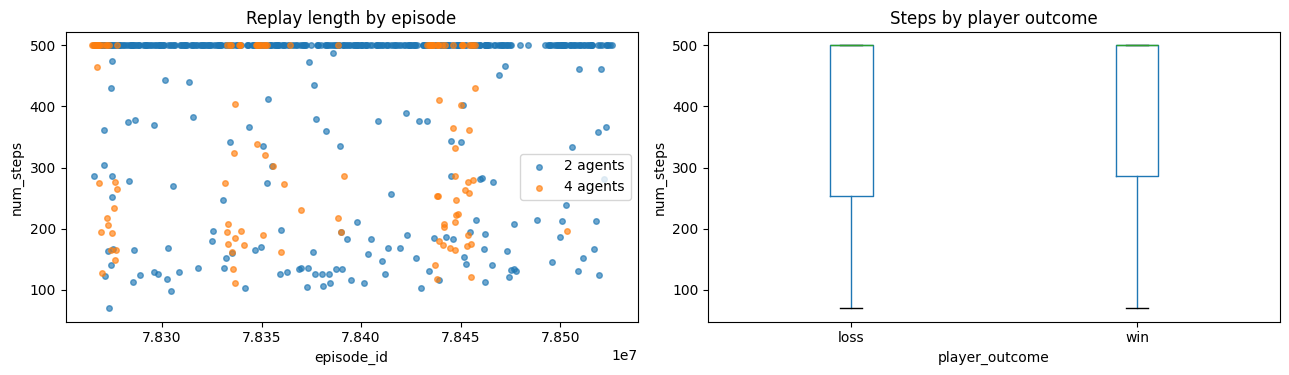

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for n_agents, grp in episode_df.groupby("n_agents"):
    axes[0].scatter(grp["episode_id"], grp["num_steps"], s=16, alpha=0.65, label=f"{n_agents} agents")
axes[0].set_title("Replay length by episode")
axes[0].set_xlabel("episode_id")
axes[0].set_ylabel("num_steps")
axes[0].legend()

order = [x for x in ["win", "loss", "tie", "unknown"] if x in set(player_df["player_outcome"])]
player_df.boxplot(column="num_steps", by="player_outcome", ax=axes[1], grid=False)
axes[1].set_title("Steps by player outcome")
axes[1].set_xlabel("player_outcome")
axes[1].set_ylabel("num_steps")
fig.suptitle("")
plt.tight_layout()

## Longest And Shortest Replays

In [8]:
cols = ["episode_id", "n_agents", "num_steps", "replay_outcome", "winner_names", "team_names", "rewards", "statuses", "file"]
print("shortest")
display(episode_df.nsmallest(10, "num_steps")[cols])
print("longest")
display(episode_df.nlargest(10, "num_steps")[cols])

shortest


,episode_id,n_agents,num_steps,replay_outcome,winner_names,team_names,rewards,statuses,file
41,78273612,2,69,win,Isaiah @ Tufa Labs,213tubo | Isaiah @ Tufa Labs,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
120,78304739,2,98,win,typeIIIfairy,typeIIIfairy | Isaiah @ Tufa Labs,"[1, -1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
197,78341926,2,103,win,Vadasz,Vadasz | Isaiah @ Tufa Labs,"[1, -1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
374,78429852,2,103,win,typeIIIfairy,Isaiah @ Tufa Labs | typeIIIfairy,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
267,78372677,2,104,win,Zachary Ruhe,Zachary Ruhe | Isaiah @ Tufa Labs,"[1, -1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
280,78380926,2,106,win,bowwowforeach,bowwowforeach | Isaiah @ Tufa Labs,"[1, -1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
186,78336881,4,110,win,Zachary Ruhe,AntiSpiral | Zachary Ruhe | Isaiah @ Tufa Labs...,"[-1, 1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
288,78384598,2,110,win,Jake Will,Isaiah @ Tufa Labs | Jake Will,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
326,78401352,2,111,win,typeIIIfairy,Isaiah @ Tufa Labs | typeIIIfairy,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
487,78462206,2,112,win,Vadasz,Vadasz | Isaiah @ Tufa Labs,"[1, -1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...


longest


,episode_id,n_agents,num_steps,replay_outcome,winner_names,team_names,rewards,statuses,file
0,78264665,4,500,win,Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | Isaiah @ Tufa Labs | Isai...,"[-1, -1, 1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
1,78265399,4,500,win,Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | AurumData | Matheus de So...,"[1, -1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
3,78265965,2,500,win,Isaiah @ Tufa Labs,ASetiawan | Isaiah @ Tufa Labs,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
4,78266302,4,500,win,Isaiah @ Tufa Labs,Isaiah @ Tufa Labs | 新米エンジニア十一号 | Ochir Dorzhi...,"[1, -1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
5,78266514,4,500,win,Isaiah @ Tufa Labs,SYC | ajohnston7354 | 0STG0T | Isaiah @ Tufa Labs,"[-1, -1, -1, 1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
6,78266730,4,500,win,Isaiah @ Tufa Labs,Andrei Asanau | Sukjae Cho | Isaiah @ Tufa Lab...,"[-1, -1, 1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
7,78266951,2,500,win,Isaiah @ Tufa Labs,breso | Isaiah @ Tufa Labs,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
8,78266995,2,500,win,Isaiah @ Tufa Labs,IAI-RL-NapNap | Isaiah @ Tufa Labs,"[-1, 1]","[""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
9,78267298,4,500,win,Isaiah @ Tufa Labs,Jingjiang Fu | IAI-RL-NapNap | Isaiah @ Tufa L...,"[-1, -1, 1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
11,78267513,4,500,win,Isaiah @ Tufa Labs,arcobi | Isaiah @ Tufa Labs | BNBU_Thomas | Ch...,"[-1, 1, -1, -1]","[""DONE"", ""DONE"", ""DONE"", ""DONE""]",/home/sunrise/orbitwars/replays/rank1/episode-...
